In [1]:
import torch

print(f"PyTorch 버전: {torch.__version__}")
print(f"CUDA 사용 가능 여부: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU 이름: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA를 사용할 수 없습니다.")

PyTorch 버전: 2.5.1+cu118
CUDA 사용 가능 여부: True
GPU 이름: NVIDIA GeForce RTX 4060 Ti


### ORtg, DRtg, TS%, USG%, eFG% 등 비교

In [ ]:
import pandas as pd

# 1) Advanced Stats 로드: TS%, USG%, OBPM, DBPM 포함
df_adv = pd.read_csv("C:/Users/THKIM/Desktop/3-1 프로젝트/오픈데이터분석 프로젝트/gsw_2024_25_advanced_stats.csv")
if 'PLAYER' in df_adv.columns:
    df_adv = df_adv.rename(columns={'PLAYER': 'PLAYER_NAME'})
# 필요한 컬럼만 추출
df_adv = df_adv[['PLAYER_NAME', 'TS%', 'USG%', 'OBPM', 'DBPM']]

# 2) Basic Stats 로드: FGM, FG3M, FGA 포함
df_stats = pd.read_csv("C:/Users/THKIM/Desktop/3-1 프로젝트/오픈데이터분석 프로젝트/gsw_2024_25_player_stats.csv")
# 효율적 야투율(eFG%) 계산
# FGA가 0인 경우 제외하여 오류 방지
df_stats = df_stats[df_stats['FGA'] > 0]
df_stats['eFG%'] = (df_stats['FGM'] + 0.5 * df_stats['FG3M']) / df_stats['FGA']

# 3) 지표 병합: PLAYER_NAME 기준
df_proc = pd.merge(
    df_adv,
    df_stats[['PLAYER_NAME', 'eFG%']],
    on='PLAYER_NAME',
    how='inner'
)

# 4) 최종 전처리: 결측치 제거
df_proc = df_proc.dropna(subset=['TS%', 'USG%', 'eFG%', 'OBPM', 'DBPM'])

# 결과 확인
print(df_proc)  # 컬럼: PLAYER_NAME, TS%, USG%, OBPM, DBPM, eFG%

             PLAYER_NAME    TS%  USG%  OBPM  DBPM      eFG%
0          Stephen Curry  0.618  29.8   6.4   0.0  0.571940
1         Draymond Green  0.534  15.9  -2.3   2.8  0.502947
2            Buddy Hield  0.560  20.5  -0.7  -0.3  0.546438
3     Brandin Podziemski  0.557  18.3  -0.1   0.8  0.536566
4            Moses Moody  0.578  17.4  -0.9   0.0  0.544014
5       Jonathan Kuminga  0.535  27.4  -0.5  -0.1  0.494718
6           Kevon Looney  0.535  13.3  -1.0   1.3  0.517986
7   Trayce Jackson-Davis  0.587  17.1   0.3   0.9  0.576159
8         Gary Payton II  0.635  16.1  -0.5   2.0  0.625839
9             Gui Santos  0.575  13.2  -2.2   0.5  0.553073
10          Quinten Post  0.595  19.6   0.1   0.0  0.582117
11        Draymond Green  0.474  21.2  -4.6  -0.6  0.502947
12           Pat Spencer  0.455  21.2  -3.0   1.4  0.430693
13          Kevon Looney  0.539  23.5  -1.6   0.8  0.517986
14          Jackson Rowe  0.560  16.7  -0.5   1.5  0.558824
15          Yuri Collins  0.333   7.9  -

In [38]:
# 1. 전처리: df_proc 준비 완료 가정
#    -> CSV로 저장하여 재활용 가능
df_proc.to_csv('C:/Users/THKIM/Desktop/3-1 프로젝트/오픈데이터분석 프로젝트/gsw_고급지표_분석.csv', index=False, encoding='utf-8-sig')


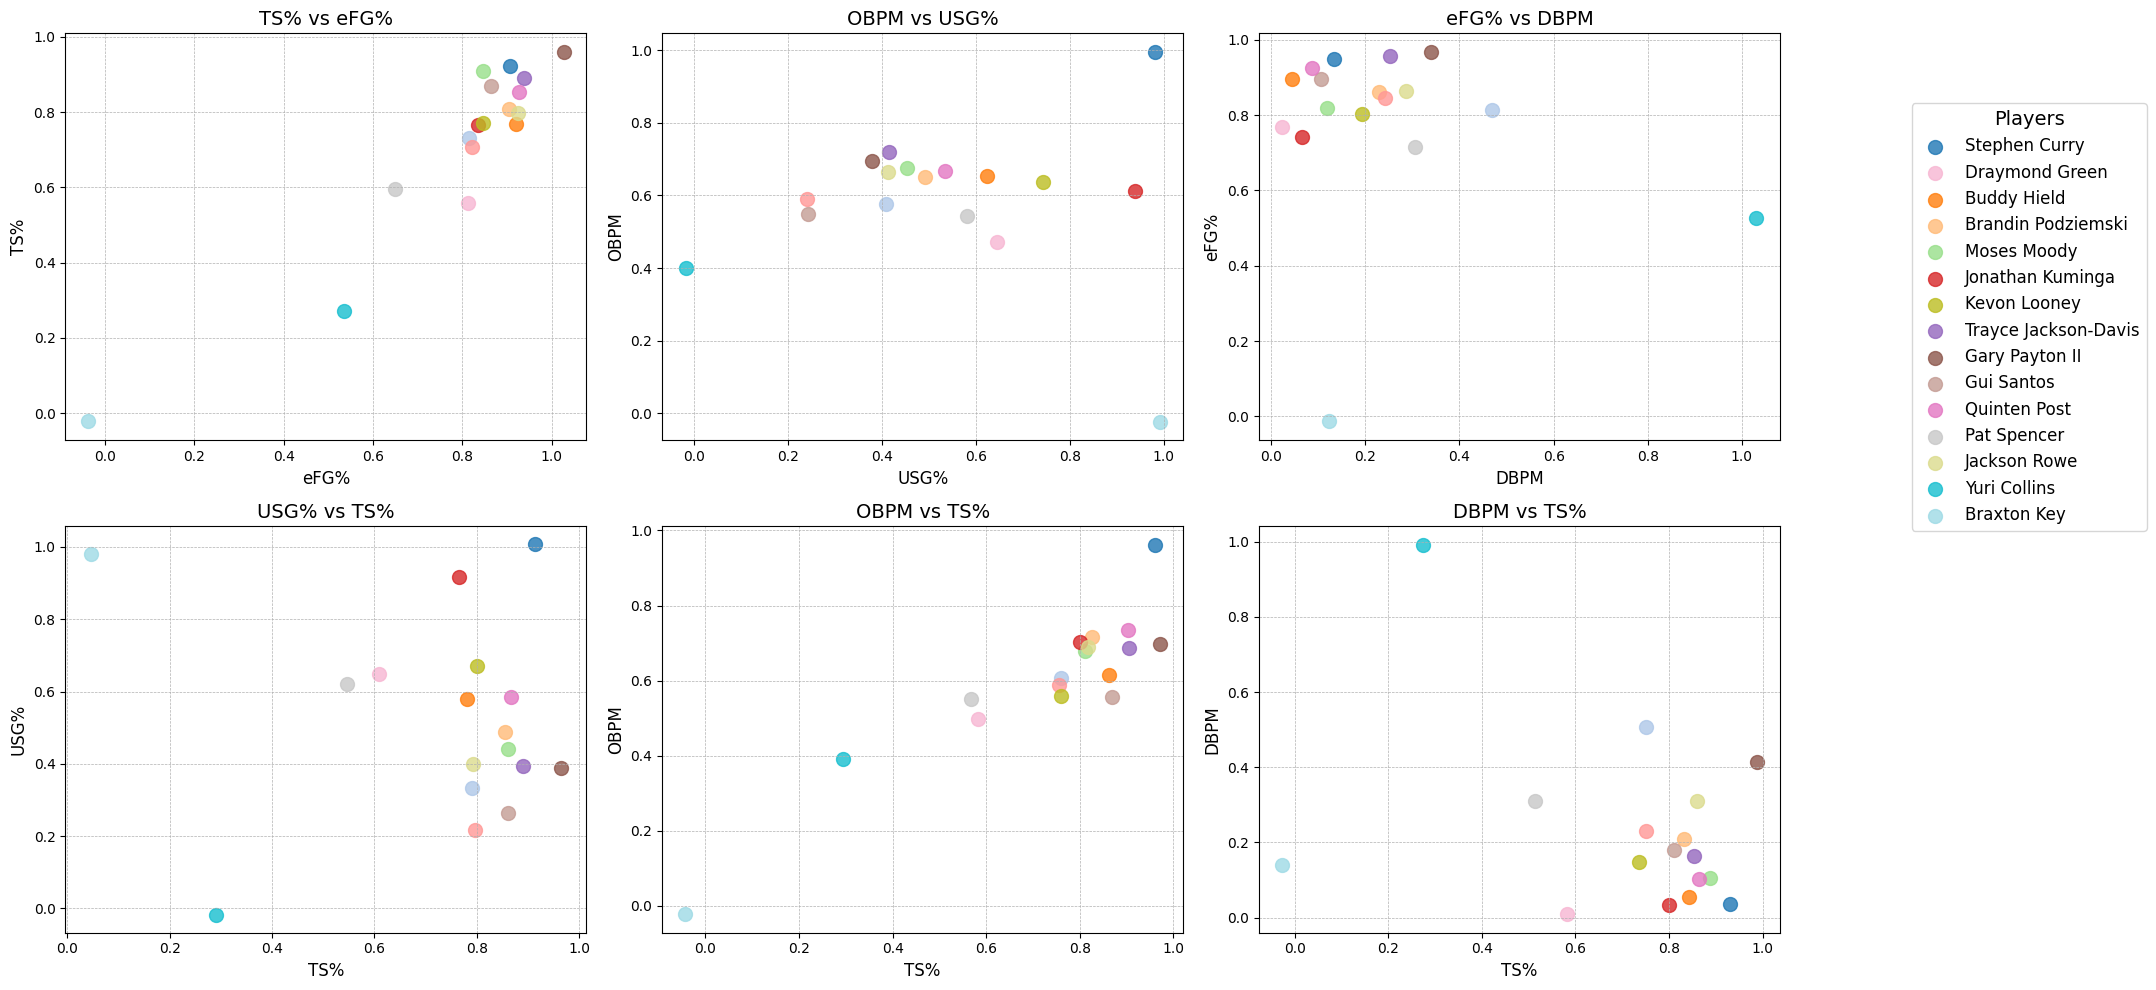

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------
# 1. 전처리: df_proc (PLAYER_NAME, TS%, USG%, eFG%, OBPM, DBPM) 준비 완료 가정
# --------------------------------------------------

# --------------------------------------------------
# 2. 정규화 (0–1 Min-Max Scaling)
metrics = ['TS%', 'USG%', 'eFG%', 'OBPM', 'DBPM']
df_norm = df_proc.copy()
for col in metrics:
    min_val, max_val = df_norm[col].min(), df_norm[col].max()
    df_norm[col] = (df_norm[col] - min_val) / (max_val - min_val)

# --------------------------------------------------
# 3. 시각화 준비
pairs = [
    ('eFG%', 'TS%'),
    ('USG%', 'OBPM'),
    ('DBPM', 'eFG%'),
    ('TS%', 'USG%'),
    ('TS%', 'OBPM'),
    ('TS%', 'DBPM')
]

total = len(pairs)
cols = 3
rows = total // cols + (1 if total % cols else 0)
fig, axes = plt.subplots(rows, cols, figsize=(cols*6, rows*5), squeeze=False)
axes = axes.flatten()

# 색상 매핑
n = len(df_norm)
colors = plt.cm.tab20(np.linspace(0,1,n))

# jitter 크기 (normalized units)
jitter = 0.05  # ±5% 범위 (값을 키워 퍼짐 효과 증대)

# --------------------------------------------------
# 4. 서브플롯별 산점도 그리기
# --------------------------------------------------
for i, (ax, (x, y)) in enumerate(zip(axes, pairs)):
    # x, y 값 (정규화)
    x_vals = df_norm[x].values
    y_vals = df_norm[y].values
    x_jit = x_vals + np.random.uniform(-jitter, jitter, size=n)
    y_jit = y_vals + np.random.uniform(-jitter, jitter, size=n)

    # 첫 플롯만 legend label 추가
    for idx, (xv, yv) in enumerate(zip(x_jit, y_jit)):
        if i == 0:
            ax.scatter(xv, yv, color=colors[idx], s=100, alpha=0.8,
                       label=df_norm['PLAYER_NAME'].iloc[idx])
        else:
            ax.scatter(xv, yv, color=colors[idx], s=100, alpha=0.8)

        # 축 범위: jitter 적용 후 범위 최소/최대 기준 동적 설정
    x_min_j, x_max_j = x_jit.min(), x_jit.max()
    y_min_j, y_max_j = y_jit.min(), y_jit.max()
    pad = jitter  # jitter 만큼 여유
    ax.set_xlim(x_min_j - pad, x_max_j + pad)
    ax.set_ylim(y_min_j - pad, y_max_j + pad)

    ax.set_xlabel(x, fontsize=12)
    ax.set_ylabel(y, fontsize=12)
    ax.set_title(f'{y} vs {x}', fontsize=14)
    ax.grid(True, linestyle='--', linewidth=0.5)

# 빈 subplot 제거
for k in range(total, len(axes)):
    fig.delaxes(axes[k])

# --------------------------------------------------
# 5. 대표 범례 추가
# --------------------------------------------------
handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
fig.legend(by_label.values(), by_label.keys(),
           loc='upper right', bbox_to_anchor=(1.2, 0.9),
           title='Players', fontsize=12, title_fontsize=14)

plt.tight_layout()
plt.show()


eFG%:Effective Field Goal Percentage	
- (FGM + 0.5 × 3PM) ÷ FGA		
- 3점슛 가치를 반영한 실질 야투 성공률	

TS%	:True Shooting Percentage	
- PTS ÷ (2 × (FGA + 0.44 × FTA))		
- 야투(eFG%) + 자유투 효율을 합쳐 “한 번의 공격 기회당” 득점 효율을 측정	

USG%:Usage Rate	
- 100 × ((FGA + 0.44×FTA + TO) × (Team Minutes)) ÷ (Minutes × (Team FGA + 0.44×Team FTA + Team TO))		
- 팀 공격 기회에서 해당 선수가 차지한 비중(볼 소유율)		

OBPM:Offensive Box Plus-Minus	
- “100번 공격 기회당” 골밑·패싱·스크린·공격 리딩을 통해 팀이 얻은 득점 이득		
- (+)면 코트에 있을 때 팀 공격력이 올라감		

DBPM:Defensive Box Plus-Minus	
- “100번 수비 기회당” 리바운드·수비 로테이션·스틸·블록으로 팀이 막아낸 실점 이득		
- (+)면 코트에 있을 때 팀 수비력이 올라감	

1. TS% vs eFG%
eFG% (Effective FG%): 2점·3점 성공률을 3점의 가치를 반영해 계산
TS% (True Shooting%): eFG%에 더해 자유투 효율까지 반영

해석

대부분 선수들이 TS% ≥ eFG% 구역(위쪽)에 위치.
차이가 큰 선수(위쪽으로 멀리 떨어진 점)는 자유투를 많이 얻어내거나, FT 효율이 높은 유형.
eFG%만 보고 지나칠 수 있는 “자유투 기회 창출력”까지 함께 볼 수 있음.

2. OBPM vs USG%
USG% (Usage Rate): 그 선수가 공격 기회에서 차지하는 비중(볼 스틸·슛 시도·턴오버 포함)
OBPM (Offensive Box Plus‐Minus): 100개 공격에서 그 선수가 코트에 있을 때 팀의 득점 이득

해석

우상단(높은 USG, 높은 OBPM): 많은 기회를 안고도 높은 효율로 팀 공격을 이끄는 에이스형
우하단(높은 USG, 낮은 OBPM): 역할에 비해 효율이 낮은 과부하형
좌상단(낮은 USG, 높은 OBPM): 적은 볼 기회에도 짧은 시간에 강력한 임팩트를 주는 벤치 핵심
좌하단(낮은 USG, 낮은 OBPM): 평균 이하의 벤치 롤 역할

3. eFG% vs DBPM
DBPM (Defensive BPM): 100개 수비 기회에서 그 선수가 있을 때 상대 실점 억제 이득

해석

우상단(높은 eFG%, 높은 DBPM): 두 말할 필요 없는 진정한 2-way 스타
우하단(높은 eFG%, 낮은 DBPM): 공격에는 특출하지만 수비 부담이 있는 스코어러
좌상단(낮은 eFG%, 높은 DBPM): 수비 스페셜리스트
좌하단(낮은 eFG%, 낮은 DBPM): 역할 재검토가 필요한 약점 노출 그룹

4. USG% vs TS%

해석

우상단(높은 USG, 높은 TS%): 많은 볼 기회 속에서도 효율을 지키는 진정한 에이스
우하단(높은 USG, 낮은 TS%): 과도한 볼 의존 대비 효율이 떨어지는 ‘볼 독점’ 리스크
좌상단(낮은 USG, 높은 TS%): 효율은 좋은데 기회가 적은 ‘숨은 효자’
좌하단(낮은 USG, 낮은 TS%): 개선 필요 롤 플레이어

5. OBPM vs TS%

해석

우상단(높은 TS%, 높은 OBPM): 효율적인 슈팅 능력 + 팀 공격 기여도 동시 우수
좌상단(높은 TS%, 낮은 OBPM): 개인 효율은 좋으나, 팀 시스템 기여로 이어지지 않을 수 있음
우하단(낮은 TS%, 높은 OBPM): 득점 효율 자체는 낮지만, 패싱·스크린·전술 실행으로 공격 생산성 기여
좌하단(낮은 TS%, 낮은 OBPM): 공격 전반에서 보완이 필요

6. DBPM vs TS%

해석

우상단(높은 TS%, 높은 DBPM): 경기 양쪽면에서 모두 기대할 수 있는 완성형
우하단(높은 TS%, 낮은 DBPM): 공격 강점 돋보이지만 수비 부담 주의
좌상단(낮은 TS%, 높은 DBPM): 수비 일등공신, 공격은 단순 역할
좌하단(낮은 TS%, 낮은 DBPM): 두 영역 모두 상대적으로 약점



In [3]:
from nba_api.stats.endpoints import BoxScoreAdvancedV2

df_game_adv = BoxScoreAdvancedV2(game_id='0022400001').get_data_frames()[0]

df_game_adv

,GAME_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_CITY,PLAYER_ID,PLAYER_NAME,NICKNAME,START_POSITION,COMMENT,MIN,...,TM_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,POSS,PIE
0,0022400001,1610612737,ATL,Atlanta,1642258,Zaccharie Risacher,Zaccharie,F,,24.000000:49,...,0.0,0.308,0.288,0.226,0.233,99.63,100.56,83.80,52,0.043
1,0022400001,1610612737,ATL,Atlanta,1630552,Jalen Johnson,Jalen,F,,38.000000:51,...,10.3,0.563,0.563,0.188,0.195,102.19,101.94,84.95,83,0.143
2,0022400001,1610612737,ATL,Atlanta,203991,Clint Capela,Clint,C,,16.000000:52,...,0.0,0.727,0.705,0.260,0.268,104.39,105.30,87.75,37,0.262
3,0022400001,1610612737,ATL,Atlanta,1630700,Dyson Daniels,Dyson,G,,40.000000:57,...,16.7,0.595,0.603,0.264,0.272,102.47,100.81,84.00,87,0.130
4,0022400001,1610612737,ATL,Atlanta,1630811,Keaton Wallace,Keaton,G,,31.000000:56,...,8.7,0.269,0.269,0.174,0.182,101.27,102.20,85.16,68,0.025
5,0022400001,1610612737,ATL,Atlanta,1626204,Larry Nance Jr.,Larry,,,27.000000:26,...,0.0,0.950,0.950,0.141,0.145,99.84,97.98,81.65,56,0.144
6,0022400001,1610612737,ATL,Atlanta,1629726,Garrison Mathews,Garrison,,,23.000000:13,...,18.2,0.000,0.258,0.097,0.103,102.71,100.27,83.56,49,0.018
7,0022400001,1610612737,ATL,Atlanta,1630168,Onyeka Okongwu,Onyeka,,,30.000000:42,...,18.8,0.682,0.682,0.192,0.197,99.49,96.95,80.79,63,0.072
8,0022400001,1610612737,ATL,Atlanta,1631223,David Roddy,David,,,5.000000:14,...,0.0,1.000,1.000,0.100,0.100,95.76,96.31,80.25,10,0.100
9,0022400001,1610612737,ATL,Atlanta,1631230,Dominick Barlow,Dominick,,DNP - Coach's Decision,None,...,NaN,NaN,NaN,0.000,0.000,NaN,NaN,NaN,0,NaN


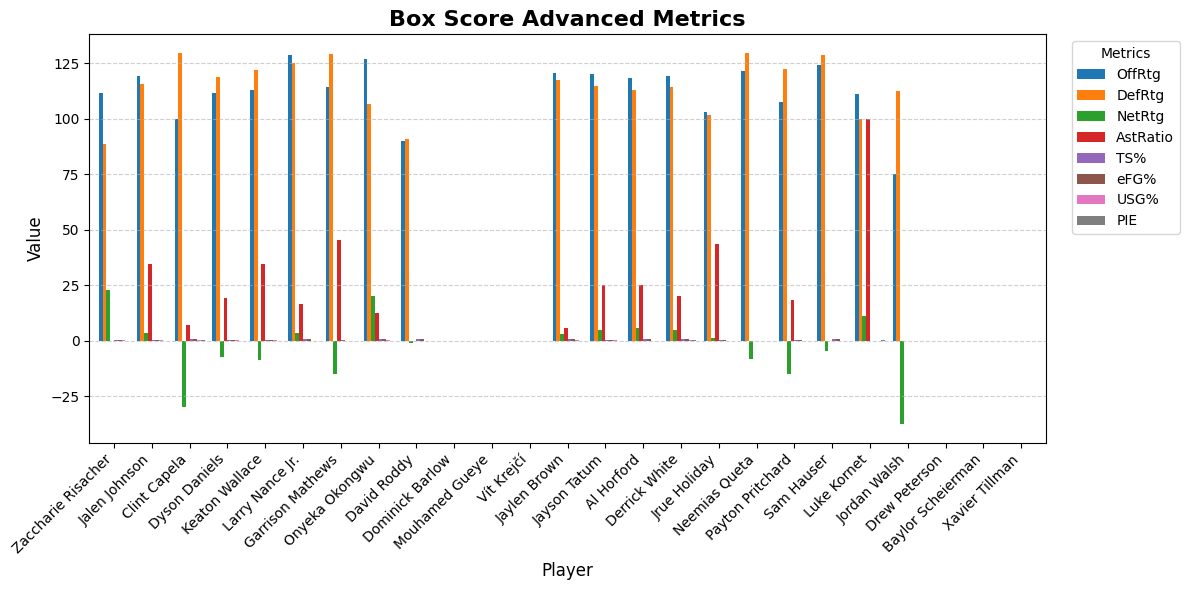

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) df_game_adv 로드됐다 가정
# print(df_game_adv.columns)  # 컬럼 확인

# 2) 시각화할 주요 고급 지표 선택
# 실제 df_game_adv.columns에 맞춰 이름을 조정하세요.
metrics = [
    'OFF_RATING',   # 공격 평점
    'DEF_RATING',   # 수비 평점
    'NET_RATING',   # 공격평점-수비평점
    'AST_RATIO',    # 어시스트 비율
    'TS_PCT',       # TS%
    'EFG_PCT',      # eFG%
    'USG_PCT',      # USG%
    'PIE'           # Player Impact Estimate
]

# 3) DataFrame 준비
df_plot = (
    df_game_adv
    .loc[:, ['PLAYER_NAME'] + [c for c in metrics if c in df_game_adv.columns]]
    .set_index('PLAYER_NAME')
)
# 컬럼명 보기 좋게 바꾸기 (선택)
df_plot = df_plot.rename(columns={
    'OFF_RATING':'OffRtg',
    'DEF_RATING':'DefRtg',
    'NET_RATING':'NetRtg',
    'AST_RATIO':'AstRatio',
    'TS_PCT':'TS%',
    'EFG_PCT':'eFG%',
    'USG_PCT':'USG%',
    'PIE':'PIE'
})

# 4) 그룹별 바 차트 그리기
ax = df_plot.plot(
    kind='bar',
    figsize=(12, 6),
    width=0.8
)
ax.set_title('Box Score Advanced Metrics', fontsize=16, weight='bold')
ax.set_ylabel('Value', fontsize=12)
ax.set_xlabel('Player', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metrics', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [27]:
import matplotlib.pyplot as plt
import pandas as pd
from nba_api.stats.endpoints import BoxScoreAdvancedV2
import numpy as np

import matplotlib.pyplot as plt
import pandas as pd
from nba_api.stats.endpoints import BoxScoreAdvancedV2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from nba_api.stats.endpoints import BoxScoreAdvancedV2
import numpy as np

# --------------------------------------------------
# 1. API 호출: 특정 경기의 고급 스탯 로드 (Warriors 게임 ID 탐색 안내)
# --------------------------------------------------
# 1.1 Warriors의 플레이오프 경기 ID 목록 조회
from nba_api.stats.endpoints import LeagueGameFinder
finder = LeagueGameFinder(
    league_id_nullable='00',         # 리그 ID
    team_id_nullable='1610612744',   # Warriors TEAM_ID
    season_nullable='2024-25',       # 시즌
    season_type_nullable='Playoffs'  # 시즌 타입
)
games_df = finder.get_data_frames()[0]
print("Available Warriors playoff games:", games_df[['GAME_ID','GAME_DATE','MATCHUP']])

# 1.2 분석할 경기 ID를 선택 (예시: 첫 번째 경기)
game_id = games_df['GAME_ID'].iloc[0]
print(f"Using game_id: {game_id}")

# 1.3 해당 경기 Advanced BoxScore 데이터 로드
raw = BoxScoreAdvancedV2(game_id=game_id).get_data_frames()[0]

# --------------------------------------------------
# GSW 선수만 필터링 및 시각화 준비
warriors_team_id = 1610612744

df_game_adv = raw[raw['TEAM_ID'] == warriors_team_id]
print("Warriors players:", df_game_adv['PLAYER_NAME'].tolist())

# --------------------------------------------------
# 2. 주요 고급 지표 선택 및 컬럼명 정리
# (이후 시각화 코드 연결)


metrics = [
    'OFF_RATING', 'DEF_RATING', 'NET_RATING', 'AST_RATIO',
    'TS_PCT', 'EFG_PCT', 'USG_PCT', 'PIE'
]
cols = ['PLAYER_NAME'] + [c for c in metrics if c in df_game_adv.columns]
df_plot = df_game_adv[cols].set_index('PLAYER_NAME')
df_plot.rename(columns={
    'OFF_RATING':'OffRtg', 'DEF_RATING':'DefRtg', 'NET_RATING':'NetRtg',
    'AST_RATIO':'AstRatio', 'TS_PCT':'TS%', 'EFG_PCT':'eFG%',
    'USG_PCT':'USG%', 'PIE':'PIE'
}, inplace=True)

Available Warriors playoff games:       GAME_ID   GAME_DATE      MATCHUP
0  0042400154  2025-04-28  GSW vs. HOU
1  0042400153  2025-04-26  GSW vs. HOU
2  0042400152  2025-04-23    GSW @ HOU
3  0042400151  2025-04-20    GSW @ HOU
Using game_id: 0042400154
Warriors players: ['Buddy Hield', 'Jimmy Butler III', 'Draymond Green', 'Brandin Podziemski', 'Stephen Curry', 'Gary Payton II', 'Quinten Post', 'Gui Santos', 'Kevon Looney', 'Moses Moody', 'Trayce Jackson-Davis', 'Braxton Key', 'Kevin Knox II', 'Jonathan Kuminga', 'Pat Spencer']


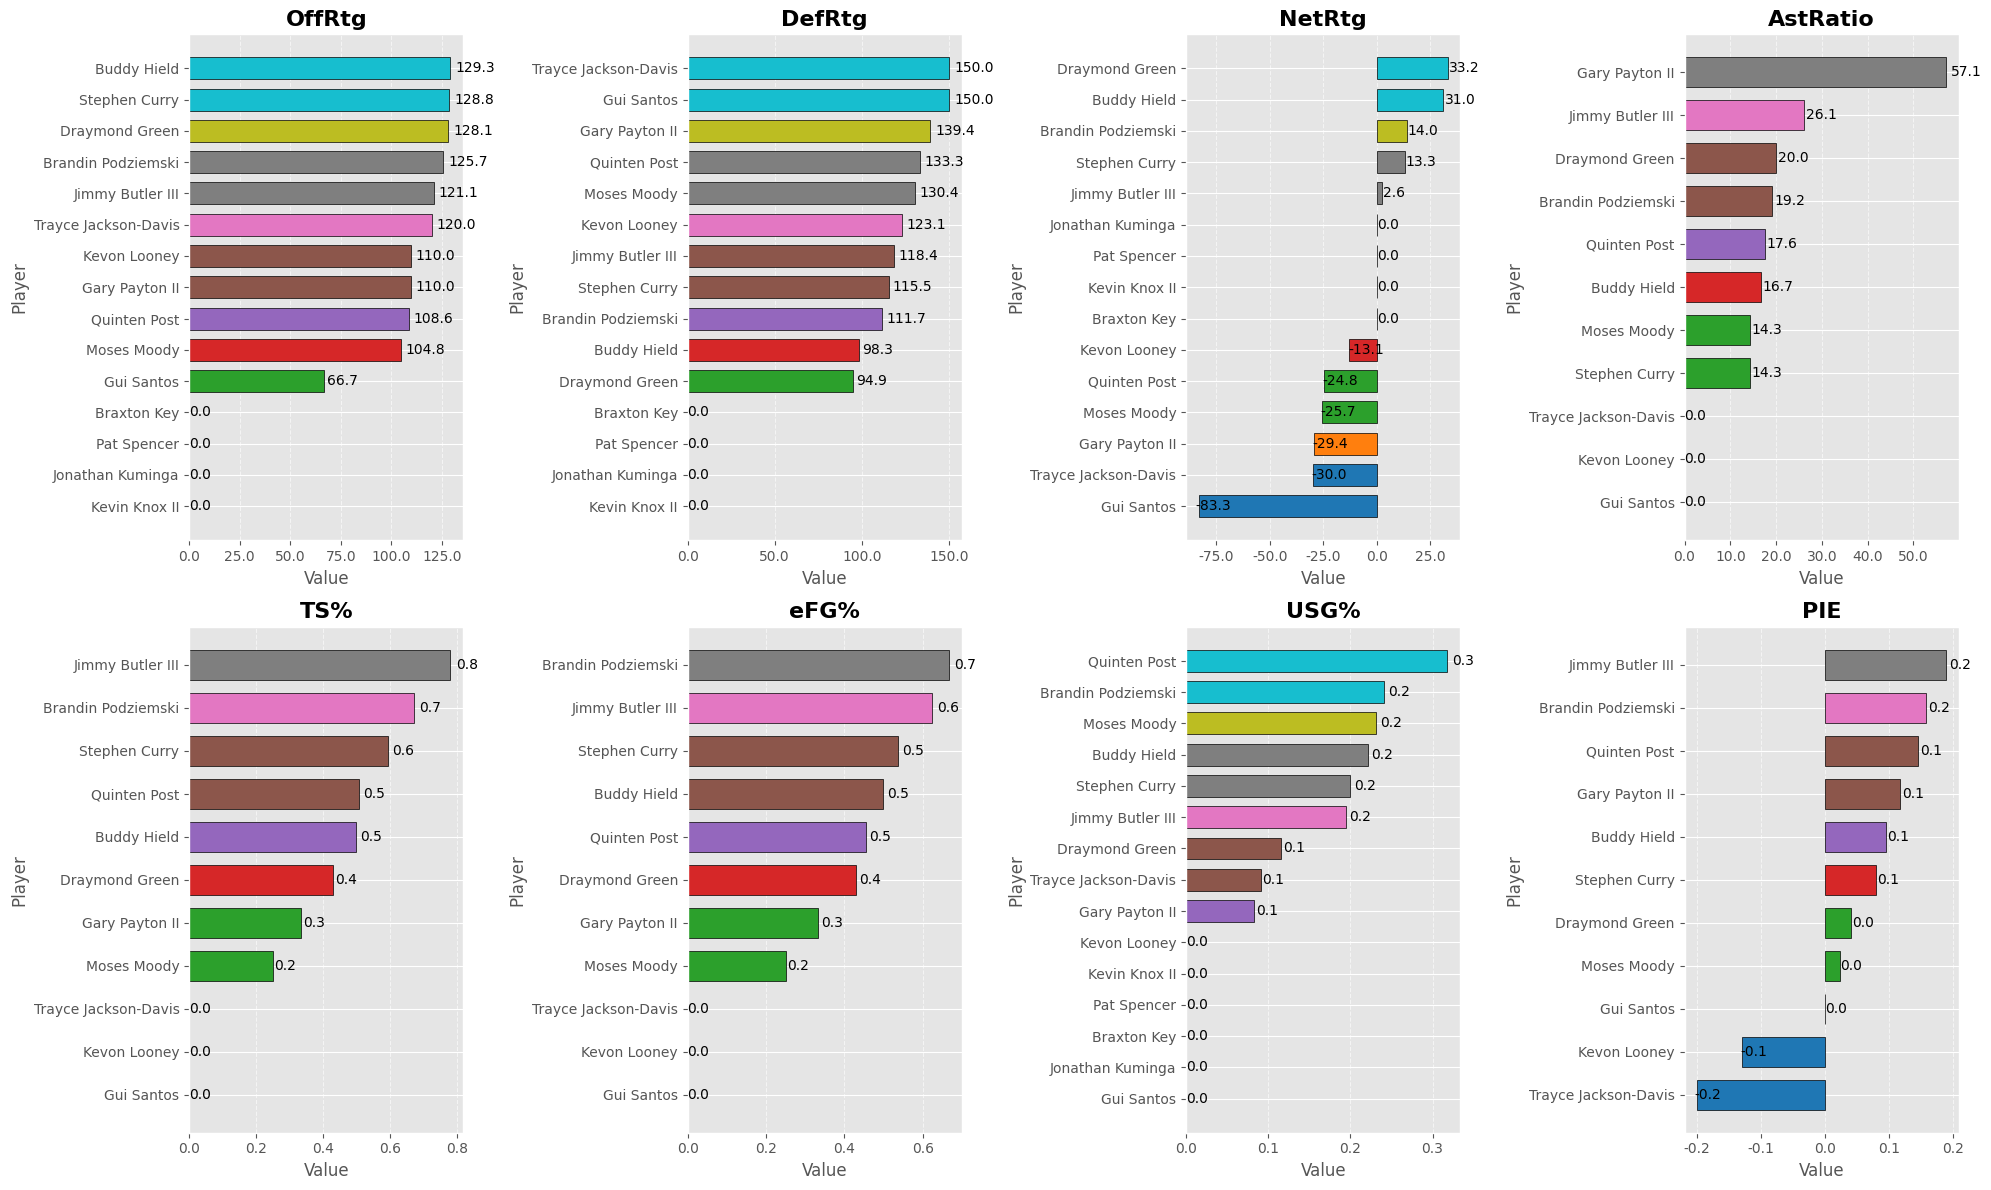

In [28]:
plt.style.use('ggplot')
fig, axes = plt.subplots(2, 4, figsize=(20, 12), sharey=False)
axes = axes.flatten()
# 색상 팔레트
dark_palette = plt.get_cmap('tab10')

for ax, metric in zip(axes, df_plot.columns):
    # 지표 값 정렬
    data = df_plot[metric].sort_values()
    colors = dark_palette(np.linspace(0, 1, len(data)))
    # 수평 바 차트
    bars = ax.barh(
        data.index,
        data.values,
        color=colors,
        edgecolor='black',
        height=0.7
    )
    # 값 레이블 추가
    for bar in bars:
        w = bar.get_width()
        ax.text(
            w + w*0.02,
            bar.get_y() + bar.get_height()/2,
            f'{w:.1f}',
            va='center', ha='left', fontsize=10
        )
    # 타이틀 및 축 설정
    ax.set_title(metric, fontsize=16, weight='bold')
    ax.set_xlabel('Value', fontsize=12)
    ax.set_ylabel('Player', fontsize=12)
    ax.tick_params(axis='y', labelsize=10)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}'))
    ax.grid(axis='x', linestyle='--', alpha=0.6)

# 남은 서브플롯 제거
for j in range(len(df_plot.columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()